# Decision Tree & Random Forest

## 1. Импорты и конфигурация

In [1]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import joblib
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

RANDOM_STATE = 42
DATA_PATH  = Path('../../data/train_data_v2.csv')
MODELS_DIR = Path('../../models')
MODELS_DIR.mkdir(exist_ok=True)

c:\Users\steel\Documents\Python Projects\GeoATM-popularity\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Загрузка данных и признаки

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Датасет: {df.shape[0]} строк x {df.shape[1]} колонок')
print(f'Таргет: min={df["target"].min():.4f}  max={df["target"].max():.4f}  mean={df["target"].mean():.4f}')

BINARY_FEATURES = [
    'is_24_7', 'contactless_tech', 'qr_codes', 'usd_available', 'eur_available',
    'cash_in', 'cash_out', 'cashless_pay', 'account_statement', 'access_for_disabled',
    'transfer_p2p', 'transfer_a2a', 'loan_payments',
    'is_federal_city', 'is_federal_district_capital', 'is_city_center', 'has_subway_nearby',
]

DISTANCE_FEATURES = [
    'nearest_malls_dist_m', 'nearest_supermarkets_dist_m',
    'nearest_pharmacies_hospitals_dist_m', 'nearest_cafes_dist_m',
    'nearest_restaurants_dist_m', 'nearest_public_transport_dist_m',
    'nearest_parking_dist_m', 'nearest_education_dist_m',
    'nearest_subway_dist_m', 'nearest_post_offices_dist_m',
    'nearest_offices_dist_m', 'nearest_shops_food_small_dist_m',
    'nearest_fitness_sport_dist_m', 'nearest_hotels_hostels_dist_m',
    'land_use_dist_m', 'city_center_dist_m', 'nearest_residential_landuse_dist_m',
]

COUNT_FEATURES = [
    'count_malls_300m', 'count_supermarkets_300m',
    'count_pharmacies_hospitals_300m', 'count_banks_atms_300m',
    'count_cafes_300m', 'count_restaurants_300m',
    'count_public_transport_300m', 'count_parking_300m',
    'count_education_300m', 'count_post_offices_300m',
    'count_offices_300m', 'count_payment_terminals_300m',
    'count_money_transfer_300m', 'count_shops_food_small_300m',
    'count_hypermarkets_300m', 'count_markets_300m',
    'count_fitness_sport_300m', 'count_hotels_hostels_300m',
    'count_railway_stations_300m', 'count_residential_buildings_300m',
    'count_residential_landuse_300m', 'count_fuel_300m',
    'count_highway_pedestrian_300m', 'count_landuse_mix_300m',
    'count_footway_100m_100m',
]

ECONOMIC_FEATURES = [
    'avg_salary_oct_2025_rub', 'grp_per_capita_2023_rub',
    'avg_income_q3_2025_rub', 'population_density_per_km2',
]

CATEGORICAL_FEATURES = [
    'federal_district', 'city_size_category', 'land_use_type', 'atm_group',
]

ALL_FEATURES = (
    BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES +
    ECONOMIC_FEATURES + CATEGORICAL_FEATURES
)
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
print(f'Итого признаков : {len(ALL_FEATURES)}')
print(f'  Бинарных      : {len(BINARY_FEATURES)}')
print(f'  Расстояний    : {len(DISTANCE_FEATURES)}')
print(f'  Count (300m)  : {len(COUNT_FEATURES)}')
print(f'  Экономических : {len(ECONOMIC_FEATURES)}')
print(f'  Категориальных: {len(CATEGORICAL_FEATURES)}')

Датасет: 6200 строк x 134 колонок
Таргет: min=-0.1450  max=0.2186  mean=0.0008
Итого признаков : 67
  Бинарных      : 17
  Расстояний    : 17
  Count (300m)  : 25
  Экономических : 4
  Категориальных: 4


## 3. Подготовка данных (70/15/15)

**Разбивка train / val / test = 70% / 15% / 15%**  
- Optuna оптимизирует **5-fold CV на train** (нет early stopping у деревьев)  
- val в этом ноутбуке не используется для подбора гиперпараметров  
- **test** используется только для финальной оценки - один раз, в конце

In [3]:
X = df[ALL_FEATURES].copy()
y = df['target'].values

for col in BINARY_FEATURES:
    if col in X.columns and X[col].dtype == bool:
        X[col] = X[col].astype(int)

for col in DISTANCE_FEATURES:
    if col in X.columns:
        X[col] = np.log1p(X[col].clip(lower=0))

for col in CATEGORICAL_FEATURES:
    if col in X.columns:
        X[col] = X[col].fillna('unknown').astype(str)

strat_col = df['city_size_category'].fillna('unknown')

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=strat_col,
)
strat_trainval = strat_col.loc[X_trainval.index]
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,
    random_state=RANDOM_STATE,
    stratify=strat_trainval,
)

print(f'Train : {X_train.shape}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Val   : {X_val.shape}  ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test  : {X_test.shape}  ({len(X_test)/len(X)*100:.0f}%)')

Train : (4339, 67)  (70%)
Val   : (931, 67)  (15%)
Test  : (930, 67)  (15%)


## 4. Препроцессинг

sklearn-деревья не поддерживают `category` dtype и NaN - нужен явный препроцессинг.  
Используем `OrdinalEncoder` вместо OneHotEncoder: деревьям достаточно порядкового кодирования,  
OHE раздул бы размерность до ~200+ фичей из-за `federal_district` и `city_size_category`.

Препроцессинг делается **однократно** до Optuna для ускорения триалов.

In [4]:
num_cols = [c for c in BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES + ECONOMIC_FEATURES
            if c in X_train.columns]
cat_cols = [c for c in CATEGORICAL_FEATURES if c in X_train.columns]

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ]), cat_cols),
], remainder='drop', verbose_feature_names_out=True)

X_train_prep    = preprocessor.fit_transform(X_train)
X_val_prep      = preprocessor.transform(X_val)
X_test_prep     = preprocessor.transform(X_test)
X_trainval_prep = preprocessor.transform(X_trainval)
feat_names      = preprocessor.get_feature_names_out()

# Убираем префиксы трансформеров для красивых названий на графиках
feat_names_clean = [n.split('__', 1)[-1] if '__' in n else n for n in feat_names]

print(f'Train prep shape : {X_train_prep.shape}')
print(f'Val   prep shape : {X_val_prep.shape}')
print(f'Test  prep shape : {X_test_prep.shape}')
print(f'Признаков после препроцессинга: {X_train_prep.shape[1]}')

Train prep shape : (4339, 67)
Val   prep shape : (931, 67)
Test  prep shape : (930, 67)
Признаков после препроцессинга: 67


## 5. Baseline: Decision Tree

In [5]:
def report_metrics(model_name, model, X_tr, y_tr, X_te, y_te, fit_time):
    t0 = time.perf_counter()
    y_pred_train = model.predict(X_tr)
    train_pred_time = time.perf_counter() - t0
    t0 = time.perf_counter()
    y_pred_test = model.predict(X_te)
    test_pred_time = time.perf_counter() - t0
    def _m(yt, yp):
        return {'RMSE': round(float(np.sqrt(mean_squared_error(yt, yp))), 4),
                'MAE':  round(float(mean_absolute_error(yt, yp)), 4),
                'R2':   round(float(r2_score(yt, yp)), 4)}
    train_m = _m(y_tr, y_pred_train)
    test_m  = _m(y_te, y_pred_test)
    table = pd.DataFrame([
        {'Split': 'Train', **train_m, 'Fit time, s': round(fit_time, 2),
         'Predict time, s': round(train_pred_time, 4)},
        {'Split': 'Test',  **test_m,  'Fit time, s': float('nan'),
         'Predict time, s': round(test_pred_time, 4)},
    ]).set_index('Split')
    print(f'\n{model_name}')
    display(table.style.format(
        {'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2': '{:.4f}',
         'Fit time, s': '{:.2f}', 'Predict time, s': '{:.4f}'},
        na_rep='-'
    ))
    return {
        'Model': model_name,
        'Test RMSE': test_m['RMSE'], 'Test MAE': test_m['MAE'], 'Test R2': test_m['R2'],
        'Fit time, s': round(fit_time, 2), 'Predict time, s': round(test_pred_time, 4),
    }


t0 = time.perf_counter()
dt_base = DecisionTreeRegressor(
    max_depth=8,
    min_samples_leaf=20,
    min_samples_split=40,
    random_state=RANDOM_STATE,
)
dt_base.fit(X_train_prep, y_train)
fit_time_dt_base = time.perf_counter() - t0

base_dt_m = report_metrics('Baseline Decision Tree', dt_base,
                            X_train_prep, y_train, X_test_prep, y_test, fit_time_dt_base)
rmse_dt_base = base_dt_m['Test RMSE']
mae_dt_base  = base_dt_m['Test MAE']
r2_dt_base   = base_dt_m['Test R2']


Baseline Decision Tree


,RMSE,MAE,R2,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0445,0.0351,0.7338,0.03,0.0005
Test,0.0493,0.0395,0.6742,-,0.0001


## 6. Optuna: Decision Tree (80 trials)

Decision Tree не имеет early stopping - используем 5-fold CV на `X_train_prep` вместо val set.  
Оптимизируем RMSE (minimize).

In [6]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def dt_objective(trial):
    max_features_raw = trial.suggest_categorical(
        'max_features', ['sqrt', 'log2', '0.3', '0.5', '0.8', 'none']
    )
    # Конвертируем строки обратно в нужные типы
    if max_features_raw == 'none':
        max_features_val = None
    elif max_features_raw in ('sqrt', 'log2'):
        max_features_val = max_features_raw
    else:
        max_features_val = float(max_features_raw)

    params = {
        'max_depth':         trial.suggest_int('max_depth', 3, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 300),
        'criterion':         trial.suggest_categorical('criterion',
                                 ['squared_error', 'friedman_mse']),
        'max_features':      max_features_val,
        'random_state':      RANDOM_STATE,
    }
    model = DecisionTreeRegressor(**params)
    scores = cross_val_score(model, X_train_prep, y_train,
                             cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -scores.mean()

study_dt = optuna.create_study(
    direction='minimize',
    study_name='decision_tree',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_dt.optimize(dt_objective, n_trials=80, show_progress_bar=True)

print(f'\nBest RMSE (CV 5-fold): {study_dt.best_value:.4f}')
print('Best params:', study_dt.best_params)

Best trial: 54. Best value: 0.0484708: 100%|██████████| 80/80 [00:15<00:00,  5.26it/s]


Best RMSE (CV 5-fold): 0.0485
Best params: {'max_features': 'none', 'max_depth': 12, 'min_samples_leaf': 24, 'min_samples_split': 246, 'criterion': 'friedman_mse'}


## 7. Финальная модель: Decision Tree

In [ ]:
# Восстанавливаем max_features (строки -> нужные типы)
best_dt_params = {k: v for k, v in study_dt.best_params.items() if k != 'max_features'}
mf_raw = study_dt.best_params['max_features']
if mf_raw == 'none':
    best_dt_params['max_features'] = None
elif mf_raw in ('sqrt', 'log2'):
    best_dt_params['max_features'] = mf_raw
else:
    best_dt_params['max_features'] = float(mf_raw)

t0 = time.perf_counter()
dt_final = DecisionTreeRegressor(**best_dt_params, random_state=RANDOM_STATE)
dt_final.fit(X_train_prep, y_train)
fit_time_dt_final = time.perf_counter() - t0

final_dt_m = report_metrics('Final Decision Tree (Optuna)', dt_final,
                             X_train_prep, y_train, X_test_prep, y_test, fit_time_dt_final)
rmse_dt_final = final_dt_m['Test RMSE']
mae_dt_final  = final_dt_m['Test MAE']
r2_dt_final   = final_dt_m['Test R2']

print(f'\nDT: RMSE baseline {rmse_dt_base:.4f} -> Optuna {rmse_dt_final:.4f}')
print(f'DT: R2   baseline {r2_dt_base:.4f} -> Optuna {r2_dt_final:.4f}')

## 8. Baseline: Random Forest

In [8]:
t0 = time.perf_counter()
rf_base = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_base.fit(X_train_prep, y_train)
fit_time_rf_base = time.perf_counter() - t0

base_rf_m = report_metrics('Baseline Random Forest', rf_base,
                            X_train_prep, y_train, X_test_prep, y_test, fit_time_rf_base)
rmse_rf_base = base_rf_m['Test RMSE']
mae_rf_base  = base_rf_m['Test MAE']
r2_rf_base   = base_rf_m['Test R2']


Baseline Random Forest


,RMSE,MAE,R2,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0274,0.0208,0.8990,1.02,0.0475
Test,0.0446,0.0357,0.7327,-,0.0354


## 9. Optuna: Random Forest (100 trials)

Аналогично DT - 5-fold CV на `X_train_prep`.  
RF использует `n_jobs=-1` внутри, CV-фолды идут последовательно во избежание перегрузки CPU.  
Параметр `max_samples` предлагается только при `bootstrap=True`.

In [9]:
def rf_objective(trial):
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    params = {
        'n_estimators':          trial.suggest_int('n_estimators', 100, 600),
        'max_depth':             trial.suggest_int('max_depth', 5, 40),
        'min_samples_leaf':      trial.suggest_int('min_samples_leaf', 1, 20),
        'min_samples_split':     trial.suggest_int('min_samples_split', 2, 20),
        'max_features':          trial.suggest_float('max_features', 0.1, 1.0),
        'criterion':             trial.suggest_categorical('criterion',
                                     ['squared_error', 'friedman_mse']),
        'bootstrap':             bootstrap,
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease',
                                     1e-7, 1e-3, log=True),
        'random_state':          RANDOM_STATE,
        'n_jobs':                -1,
    }
    if bootstrap:
        params['max_samples'] = trial.suggest_float('max_samples', 0.5, 1.0)

    model = RandomForestRegressor(**params)
    # n_jobs=1 в cross_val_score - RF сам распараллелен через n_jobs=-1
    scores = cross_val_score(model, X_train_prep, y_train,
                             cv=kf, scoring='neg_root_mean_squared_error', n_jobs=1)
    return -scores.mean()

study_rf = optuna.create_study(
    direction='minimize',
    study_name='random_forest',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_rf.optimize(rf_objective, n_trials=100, show_progress_bar=True)

print(f'\nBest RMSE (CV 5-fold): {study_rf.best_value:.4f}')
print('Best params:', study_rf.best_params)

Best trial: 84. Best value: 0.0453874: 100%|██████████| 100/100 [04:02<00:00,  2.43s/it]


Best RMSE (CV 5-fold): 0.0454
Best params: {'bootstrap': False, 'n_estimators': 371, 'max_depth': 38, 'min_samples_leaf': 2, 'min_samples_split': 17, 'max_features': 0.3474595580837243, 'criterion': 'squared_error', 'min_impurity_decrease': 1.309250441738753e-07}


## 10. Финальная модель: Random Forest

In [ ]:
# best_params содержит только нативные параметры RF - никакого ручного разбора не нужно
best_rf_params = dict(study_rf.best_params)

t0 = time.perf_counter()
rf_final = RandomForestRegressor(**best_rf_params, random_state=RANDOM_STATE, n_jobs=-1)
rf_final.fit(X_train_prep, y_train)
fit_time_rf_final = time.perf_counter() - t0

final_rf_m = report_metrics('Final Random Forest (Optuna)', rf_final,
                             X_train_prep, y_train, X_test_prep, y_test, fit_time_rf_final)
rmse_rf_final = final_rf_m['Test RMSE']
mae_rf_final  = final_rf_m['Test MAE']
r2_rf_final   = final_rf_m['Test R2']

print(f'\nRF: RMSE baseline {rmse_rf_base:.4f} -> Optuna {rmse_rf_final:.4f}')
print(f'RF: R2   baseline {r2_rf_base:.4f} -> Optuna {r2_rf_final:.4f}')

## 11. Кросс-валидация (5-fold, Random Forest)

Дополнительная оценка устойчивости лучшей RF модели на `X_trainval_prep` (train+val).  
Показываем mean ± std RMSE / MAE / R² по фолдам.

In [11]:
print('Запускаем 5-fold CV на train+val...')
cv_results = cross_validate(
    RandomForestRegressor(**best_rf_params, random_state=RANDOM_STATE, n_jobs=-1),
    X_trainval_prep, y_trainval,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'r2':   'r2',
    },
    n_jobs=1,
    return_train_score=True,
)

cv_table = pd.DataFrame({
    'Split':   ['Train (mean)', 'Train (std)', 'Val (mean)', 'Val (std)'],
    'RMSE': [
        -cv_results['train_rmse'].mean(), cv_results['train_rmse'].std(),
        -cv_results['test_rmse'].mean(),  cv_results['test_rmse'].std(),
    ],
    'MAE': [
        -cv_results['train_mae'].mean(), cv_results['train_mae'].std(),
        -cv_results['test_mae'].mean(),  cv_results['test_mae'].std(),
    ],
    'R2': [
        cv_results['train_r2'].mean(), cv_results['train_r2'].std(),
        cv_results['test_r2'].mean(),  cv_results['test_r2'].std(),
    ],
}).set_index('Split')

print('\nRandom Forest (Optuna) - 5-fold CV на train+val:')
display(cv_table.style.format('{:.4f}'))

# Короткая сводка
val_rmse_mean = -cv_results['test_rmse'].mean()
val_rmse_std  =  cv_results['test_rmse'].std()
val_r2_mean   =  cv_results['test_r2'].mean()
print(f'\nCV Val RMSE: {val_rmse_mean:.4f} +/- {val_rmse_std:.4f}')
print(f'CV Val R2  : {val_r2_mean:.4f}')

Запускаем 5-fold CV на train+val...

Random Forest (Optuna) - 5-fold CV на train+val:


,RMSE,MAE,R2
Split,,,
Train (mean),0.0204,0.0155,0.9436
Train (std),0.0002,0.0001,0.0011
Val (mean),0.0449,0.0352,0.7258
Val (std),0.0011,0.0005,0.0113



CV Val RMSE: 0.0449 +/- 0.0011
CV Val R2  : 0.7258


## 12. Важность признаков

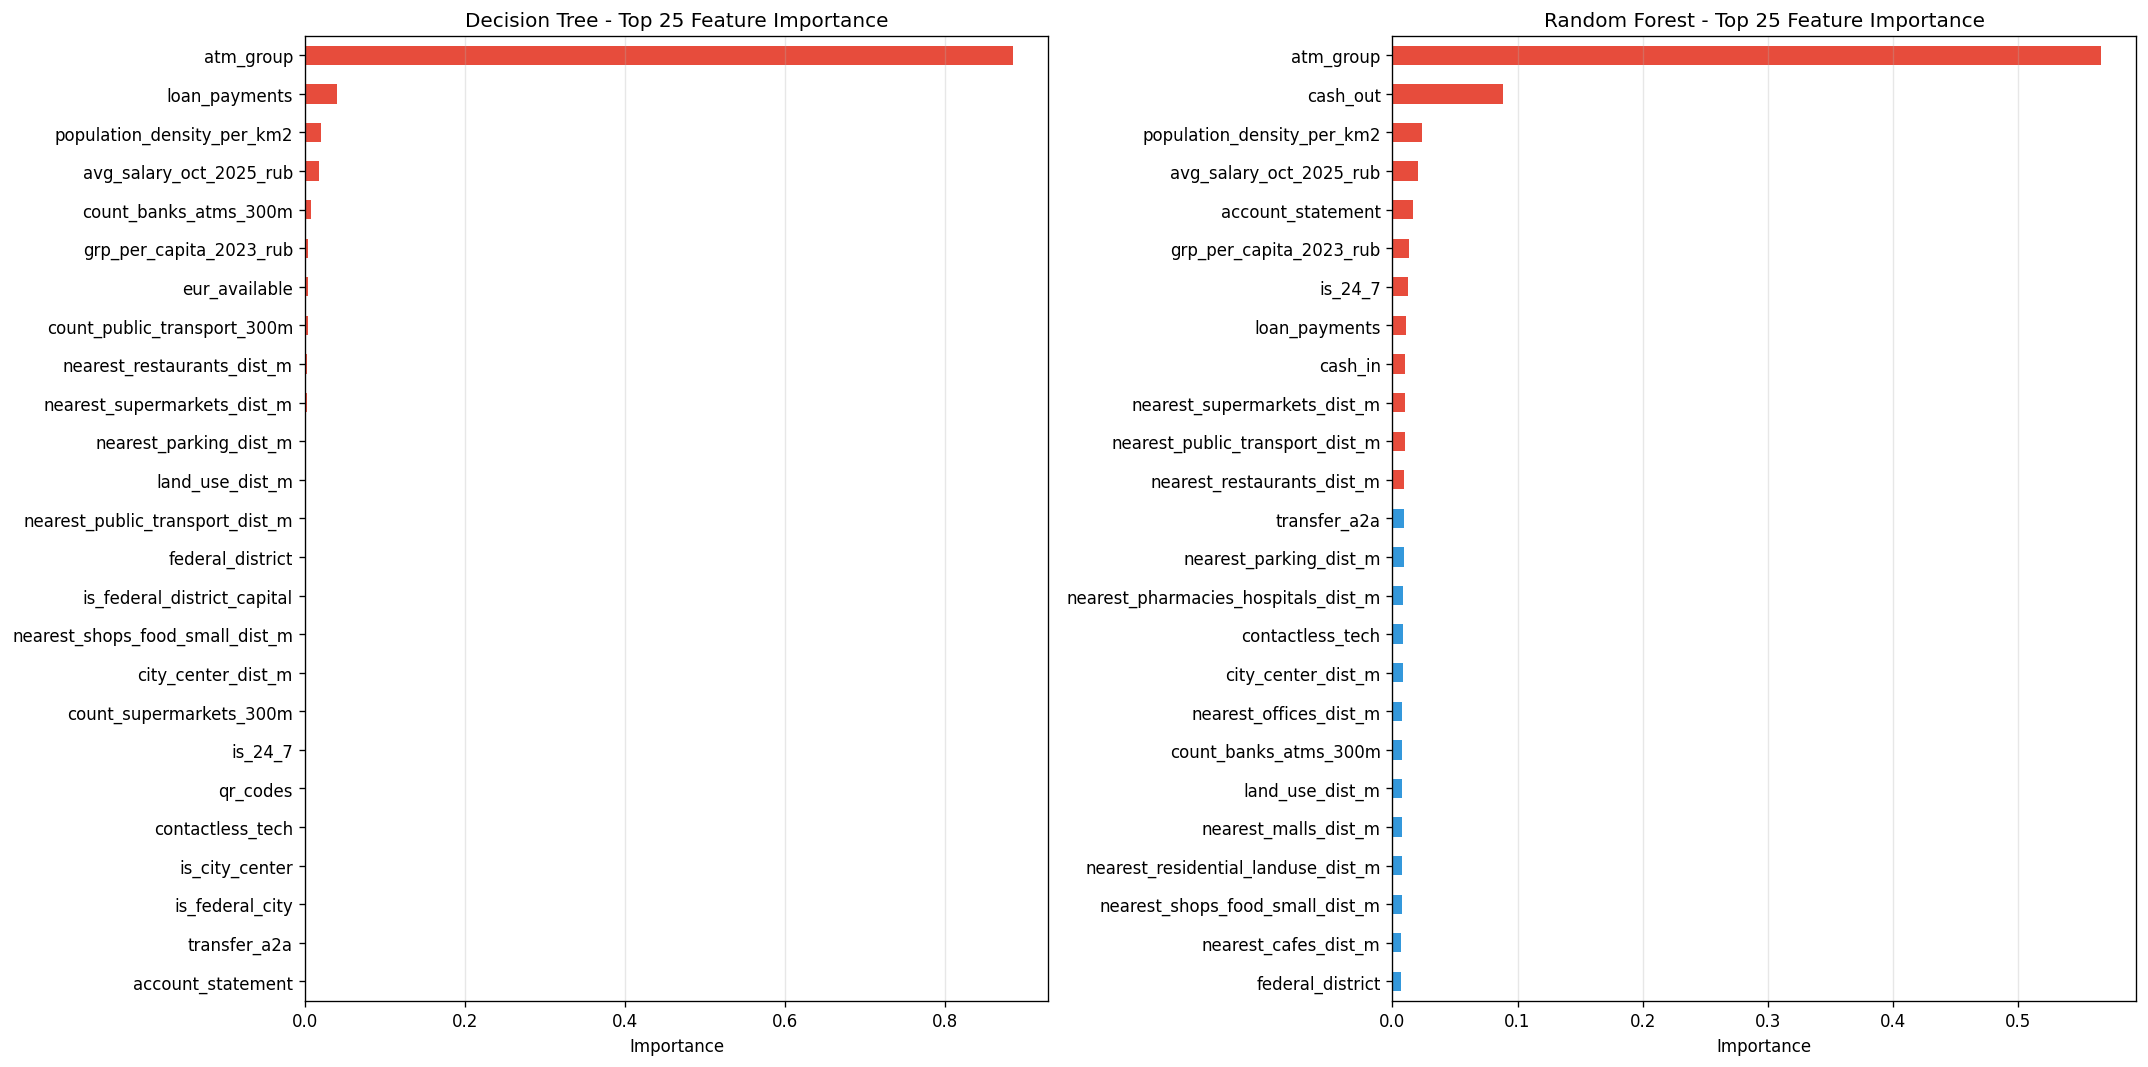


Decision Tree - Top 15:
atm_group                         0.8844
loan_payments                     0.0405
population_density_per_km2        0.0207
avg_salary_oct_2025_rub           0.0179
count_banks_atms_300m             0.0074
grp_per_capita_2023_rub           0.0046
eur_available                     0.0041
count_public_transport_300m       0.0039
nearest_restaurants_dist_m        0.0032
nearest_supermarkets_dist_m       0.0024
nearest_parking_dist_m            0.0023
land_use_dist_m                   0.0021
nearest_public_transport_dist_m   0.0016
federal_district                  0.0015
is_federal_district_capital       0.0011

Random Forest - Top 15:
atm_group                             0.5658
cash_out                              0.0885
population_density_per_km2            0.0233
avg_salary_oct_2025_rub               0.0205
account_statement                     0.0169
grp_per_capita_2023_rub               0.0130
is_24_7                               0.0127
loan_payments       

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, model, title in [
    (axes[0], dt_final, 'Decision Tree - Top 25 Feature Importance'),
    (axes[1], rf_final, 'Random Forest - Top 25 Feature Importance'),
]:
    fi = pd.Series(model.feature_importances_, index=feat_names_clean)
    top25 = fi.sort_values(ascending=False).head(25).iloc[::-1]
    median_imp = top25.median()
    colors = ['#e74c3c' if v > median_imp else '#3498db' for v in top25.values]
    top25.plot.barh(ax=ax, color=colors)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Importance')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Top-15 по тексту для обеих моделей
fi_dt = pd.Series(dt_final.feature_importances_, index=feat_names_clean).sort_values(ascending=False)
fi_rf = pd.Series(rf_final.feature_importances_, index=feat_names_clean).sort_values(ascending=False)

print('\nDecision Tree - Top 15:')
print(fi_dt.head(15).to_string())
print('\nRandom Forest - Top 15:')
print(fi_rf.head(15).to_string())

## 13. Итоги

In [13]:
summary = pd.DataFrame([
    {'Эксперимент': 'DT Baseline',
     'RMSE': rmse_dt_base,  'MAE': mae_dt_base,  'R2': r2_dt_base,
     'Fit time, s': base_dt_m['Fit time, s'],  'Predict time, s': base_dt_m['Predict time, s']},
    {'Эксперимент': 'DT Optuna',
     'RMSE': rmse_dt_final, 'MAE': mae_dt_final, 'R2': r2_dt_final,
     'Fit time, s': final_dt_m['Fit time, s'], 'Predict time, s': final_dt_m['Predict time, s']},
    {'Эксперимент': 'RF Baseline',
     'RMSE': rmse_rf_base,  'MAE': mae_rf_base,  'R2': r2_rf_base,
     'Fit time, s': base_rf_m['Fit time, s'],  'Predict time, s': base_rf_m['Predict time, s']},
    {'Эксперимент': 'RF Optuna',
     'RMSE': rmse_rf_final, 'MAE': mae_rf_final, 'R2': r2_rf_final,
     'Fit time, s': final_rf_m['Fit time, s'], 'Predict time, s': final_rf_m['Predict time, s']},
]).set_index('Эксперимент')

display(
    summary.style
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2': '{:.4f}',
             'Fit time, s': '{:.2f}', 'Predict time, s': '{:.4f}'})
    .apply(lambda s: ['font-weight: bold' if v == s.min() else '' for v in s], subset=['RMSE', 'MAE'])
    .apply(lambda s: ['font-weight: bold' if v == s.max() else '' for v in s], subset=['R2'])
)

,RMSE,MAE,R2,"Fit time, s","Predict time, s"
Эксперимент,,,,,
DT Baseline,0.0493,0.0395,0.6742,0.03,0.0001
DT Optuna,0.0484,0.0388,0.6858,0.04,0.0001
RF Baseline,0.0446,0.0357,0.7327,1.02,0.0354
RF Optuna,0.0444,0.0353,0.7359,0.75,0.0455


## 14. Сохранение моделей

Для production-чистоты препроцессор переобучается на `X_trainval` (train+val),  
после чего собирается единый `Pipeline` - принимает сырой DataFrame, возвращает предсказания.

In [15]:
# Препроцессор переобучается на train+val, затем на тех же данных обучаются финальные модели —
# так и препроцессор, и деревья видели одинаковое множество, пороги и коды совпадают.
preprocessor_save = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ]), cat_cols),
], remainder='drop', verbose_feature_names_out=True)
preprocessor_save.fit(X_trainval)
X_trainval_prep_save = preprocessor_save.transform(X_trainval)

dt_save = DecisionTreeRegressor(**best_dt_params, random_state=RANDOM_STATE)
dt_save.fit(X_trainval_prep_save, y_trainval)

rf_save = RandomForestRegressor(**best_rf_params, random_state=RANDOM_STATE, n_jobs=-1)
rf_save.fit(X_trainval_prep_save, y_trainval)
print('DT и RF финально обучены на train+val (препроцессор тот же)')

dt_pipeline = Pipeline([('prep', preprocessor_save), ('model', dt_save)])
rf_pipeline = Pipeline([('prep', preprocessor_save), ('model', rf_save)])

dt_path = MODELS_DIR / 'dt_best.joblib'
rf_path = MODELS_DIR / 'rf_best.joblib'

joblib.dump(dt_pipeline, dt_path)
joblib.dump(rf_pipeline, rf_path)

print(f'DT pipeline saved -> {dt_path}')
print(f'RF pipeline saved -> {rf_path}')

DT и RF финально обучены на train+val (препроцессор тот же)
DT pipeline saved -> ..\..\models\dt_best.joblib
RF pipeline saved -> ..\..\models\rf_best.joblib
